## Filtering Techniques

- In image processing, filtering is used to modify an image by changing the intensity of pixels based on their neighboring pixels.

Filtering commnly used for:
- Noise reduction: Filters can help remove unwanted noise from an image, making it clearer and more visually appealing.
- Edge detection: Filters can enhance the edges in an image, making it easier to identify shapes and objects.
- Image sharpening: Filters can enhance the details in an image, making it appear sharper and more defined.
- Image smoothing / Blurring: Filters can be used to smooth out an image, reducing harsh transitions and creating a more uniform appearance.
- Feature extraction: Filters can help highlight specific features in an image, such as textures or patterns, which can be useful for analysis and recognition tasks.

#### How Image Filtering Works

Suppose we have a grayscale image:

$$ I = \begin{bmatrix} 10 & 20 & 30\\ 40 & 50 & 60\\ 70 & 80 & 90 \end{bmatrix} $$

And a filter/kernel:

$$ K = \begin{bmatrix} 1 & 1 & 1\\ 1 & 1 & 1\\ 1 & 1 & 1 \end{bmatrix} $$

We slide the kernel over the image and perform an operation such as multiplication + summation.

This operation is called convolution.

More generally:

$$ O(x,y)=\sum_i\sum_j I(x+i,y+j)K(i,j) $$

where:

\(I\) = input image
\(K\) = kernel
\(O\) = output image

Types of Filters:
1. Linear Filters: These filters apply a linear transformation to the pixel values in an image.
2. Non-linear Filters: These filters apply a non-linear transformation to the pixel values in an image, often used for noise reduction and edge detection.

### Mean Filter:
- The mean filter is a linear filter that replaces each pixel value in an image with the average

The mean filter replaces a pixel with the average of its neighboring pixels.

For example:

$$ K=\frac{1}{9} \begin{bmatrix} 1&1&1\\ 1&1&1\\ 1&1&1 \end{bmatrix} $$

For a 3×3 neighborhood:

New Pixel=
	​


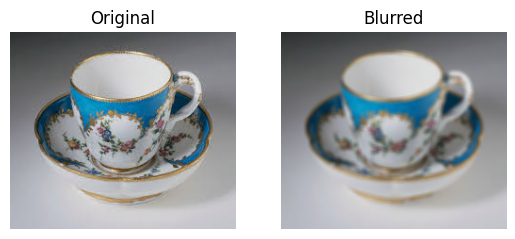

In [20]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('C:\\Users\\Debasish Das\\Desktop\\Computer-Vision-Resources\\dataset\\images (1).jpg')

filtered = cv2.blur(image, (5, 5))

# Display the original and filtered images
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
plt.title("Blurred")
plt.axis("off")

plt.show()


### Gassian Filter:
- The Gaussian filter is a linear filter that uses a Gaussian function to calculate the weights of neighboring pixels. It is commonly used for image smoothing and noise reduction.

Gaussian filtering uses a Gaussian distribution to assign different weights to neighboring pixels.

A 2D Gaussian is:

$$ G(x,y)= \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} $$

Pixels closer to the center receive higher weights.

For example, conceptually:

$$ K \approx \begin{bmatrix} 1&2&1\\ 2&4&2\\ 1&2&1 \end{bmatrix} $$

followed by normalization.

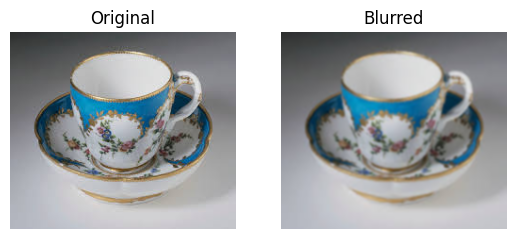

In [22]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('C:\\Users\\Debasish Das\\Desktop\\Computer-Vision-Resources\\dataset\\images (1).jpg')

filtered = cv2.GaussianBlur(image, (5, 5), sigmaX=0)

# Display the original and filtered images
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
plt.title("Blurred")
plt.axis("off")

plt.show()

### Median Filter:
- The median filter is a non-linear filter that replaces each pixel value in an image with the median of its neighboring pixel values. It is particularly effective for removing salt-and-pepper noise.

Instead of calculating the average, it takes the median of neighboring pixels.

Suppose:

```

10  12  11
13 255  14
12  15  13

```

Here 255 is an extreme noisy pixel.

Sorted values:

10 11 12 12 13 13 14 15 255

Median:

13

So the noisy 255 gets replaced by approximately 13.

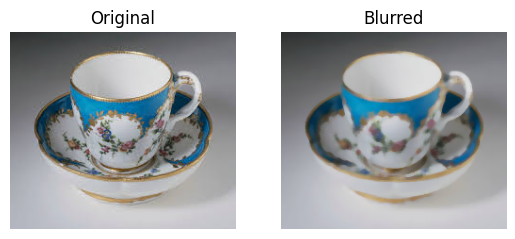

In [23]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('C:\\Users\\Debasish Das\\Desktop\\Computer-Vision-Resources\\dataset\\images (1).jpg')

filtered = cv2.medianBlur(image, 5)

# Display the original and filtered images
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
plt.title("Blurred")
plt.axis("off")

plt.show()

### Bilateral Filtering

Bilateral filtering is interesting because it tries to:

Smooth the image while preserving edges.

Unlike Gaussian filtering, bilateral filtering considers both:

Spatial distance
Intensity/color difference

Conceptually:

$$ w(p,q)= \exp\left(-\frac{||p-q||^2}{2\sigma_s^2}\right) \exp\left(-\frac{|I(p)-I(q)|^2}{2\sigma_r^2}\right) $$

So pixels that are:

close spatially
and similar in intensity

receive high weights.

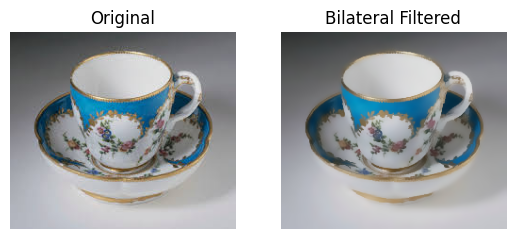

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('C:\\Users\\Debasish Das\\Desktop\\Computer-Vision-Resources\\dataset\\images (1).jpg')

# paramiter d: Diameter of each pixel neighborhood that is used during filtering. If it is non-positive, it is computed from sigmaSpace.
# paramiter sigmaColor: Filter sigma in the color space. A larger value of the parameter means that farther colors within the pixel neighborhood (see sigmaSpace) 
#  will be mixed together, resulting in larger areas of semi-equal color.
# paramiter sigmaSpace: Filter sigma in the coordinate space. A larger value of the parameter

filtered = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

# Display the original and filtered images
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
plt.title("Bilateral Filtered")
plt.axis("off")

plt.show()